In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [3]:
data = pd.read_csv('Online Retail.csv', delimiter = ',' , encoding = "ISO-8859-1")

In [4]:
data.head(10)

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [5]:
data.shape

(541909, 8)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  541909 non-null  object 
 1   StockCode     541909 non-null  object 
 2   Description   540455 non-null  object 
 3   Quantity      541909 non-null  int64  
 4   InvoiceDate   541909 non-null  object 
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
data.info

<bound method DataFrame.info of        ï»¿InvoiceNo StockCode                          Description  Quantity  \
0            536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1            536365     71053                  WHITE METAL LANTERN         6   
2            536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3            536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4            536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...             ...       ...                                  ...       ...   
541904       581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905       581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906       581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907       581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908       581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

       

In [8]:
data.describe().T # using .T we have done transpose

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [9]:
data.describe(exclude = ['int64', 'float64']).T

,count,unique,top,freq
ï»¿InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,31-10-2011 14:41,1114
Country,541909,38,United Kingdom,495478


In [10]:
data.isnull().sum()

ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

### Delete all the missing records

In [11]:
data.dropna(inplace = True)

In [12]:
data.shape

(406829, 8)

In [13]:
541909 - 406829 # How many null values we have removed.

135080

In [14]:
data[data['Quantity']<0]

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,09-12-2011 09:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,09-12-2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,09-12-2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,09-12-2011 11:58,1.25,17315.0,United Kingdom


In [15]:
data[data['UnitPrice']<0].shape[0]

0

In [16]:
data.drop(data[data['Quantity']<0].index, inplace = True)

In [17]:
data.shape

(397924, 8)

### Calculation of total amount or monetary value

In [18]:
data['Sales'] = data['Quantity']* data['UnitPrice']
new_data = data.groupby('CustomerID')['Sales'].sum().reset_index()
new_data

,CustomerID,Sales
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88


In [19]:
type(new_data)

pandas.core.frame.DataFrame

###

### Calculating the number of transactions of each customer

In [20]:
num_trans = data.groupby('CustomerID')['ï»¿InvoiceNo'].count().reset_index()

In [21]:
num_trans

,CustomerID,ï»¿InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4334,18280.0,10
4335,18281.0,7
4336,18282.0,12
4337,18283.0,756


In [22]:
type(num_trans)

pandas.core.frame.DataFrame

### Calculate Last Transaction

In [23]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], dayfirst=True)

In [24]:
data['Last Transaction'] = (data['InvoiceDate'].max() - data['InvoiceDate']).dt.days

In [25]:
data.head(10)

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Last Transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,373
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,373
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,373


In [26]:
lt = data.groupby(['CustomerID', 'Country'])['Last Transaction'].max().reset_index()

In [27]:
merge_table = pd.merge(lt, num_trans,how = 'inner', on = 'CustomerID')
new_df = pd.merge(merge_table, new_data, how = 'inner', on = 'CustomerID')
new_df

,CustomerID,Country,Last Transaction,ï»¿InvoiceNo,Sales
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40
...,...,...,...,...,...
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88


### Removing Outliers using boxplot

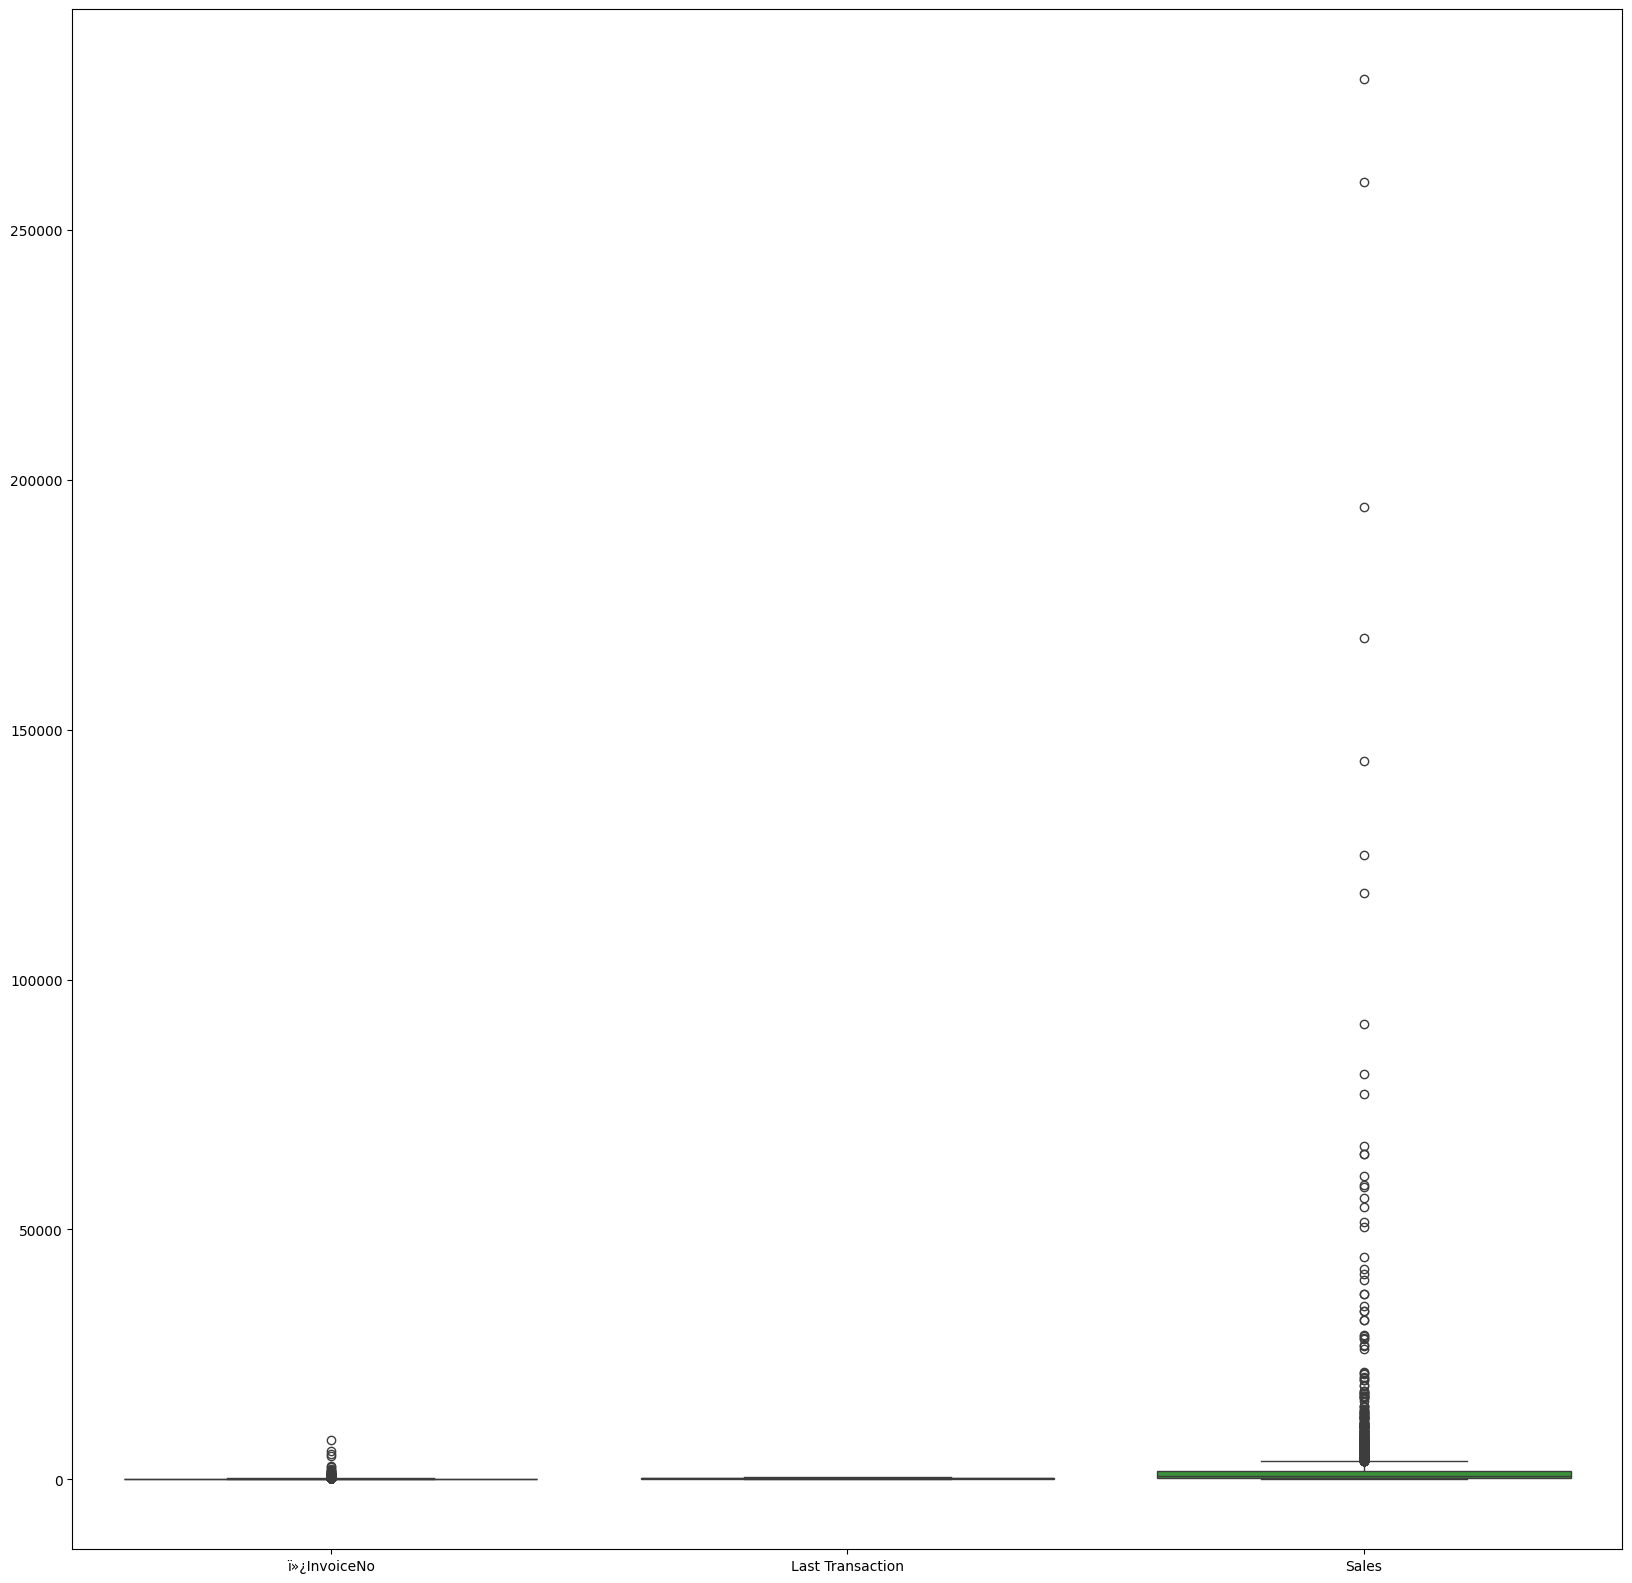

In [28]:
plt.figure(figsize=(20,20))
sns.boxplot(data = new_df[['ï»¿InvoiceNo', 'Last Transaction', 'Sales']])
plt.show()

In [29]:
IQR = new_df['Sales'].quantile(0.75) - new_df['Sales'].quantile(0.25)
lower_limit = new_df['Sales'].quantile(0.25) - 1.5*IQR
upper_limit = new_df['Sales'].quantile(0.75) + 1.5*IQR
new_df_iqr = new_df[(new_df['Sales']< upper_limit) & (new_df['Sales']>lower_limit)]
new_df_iqr.shape

(3923, 5)

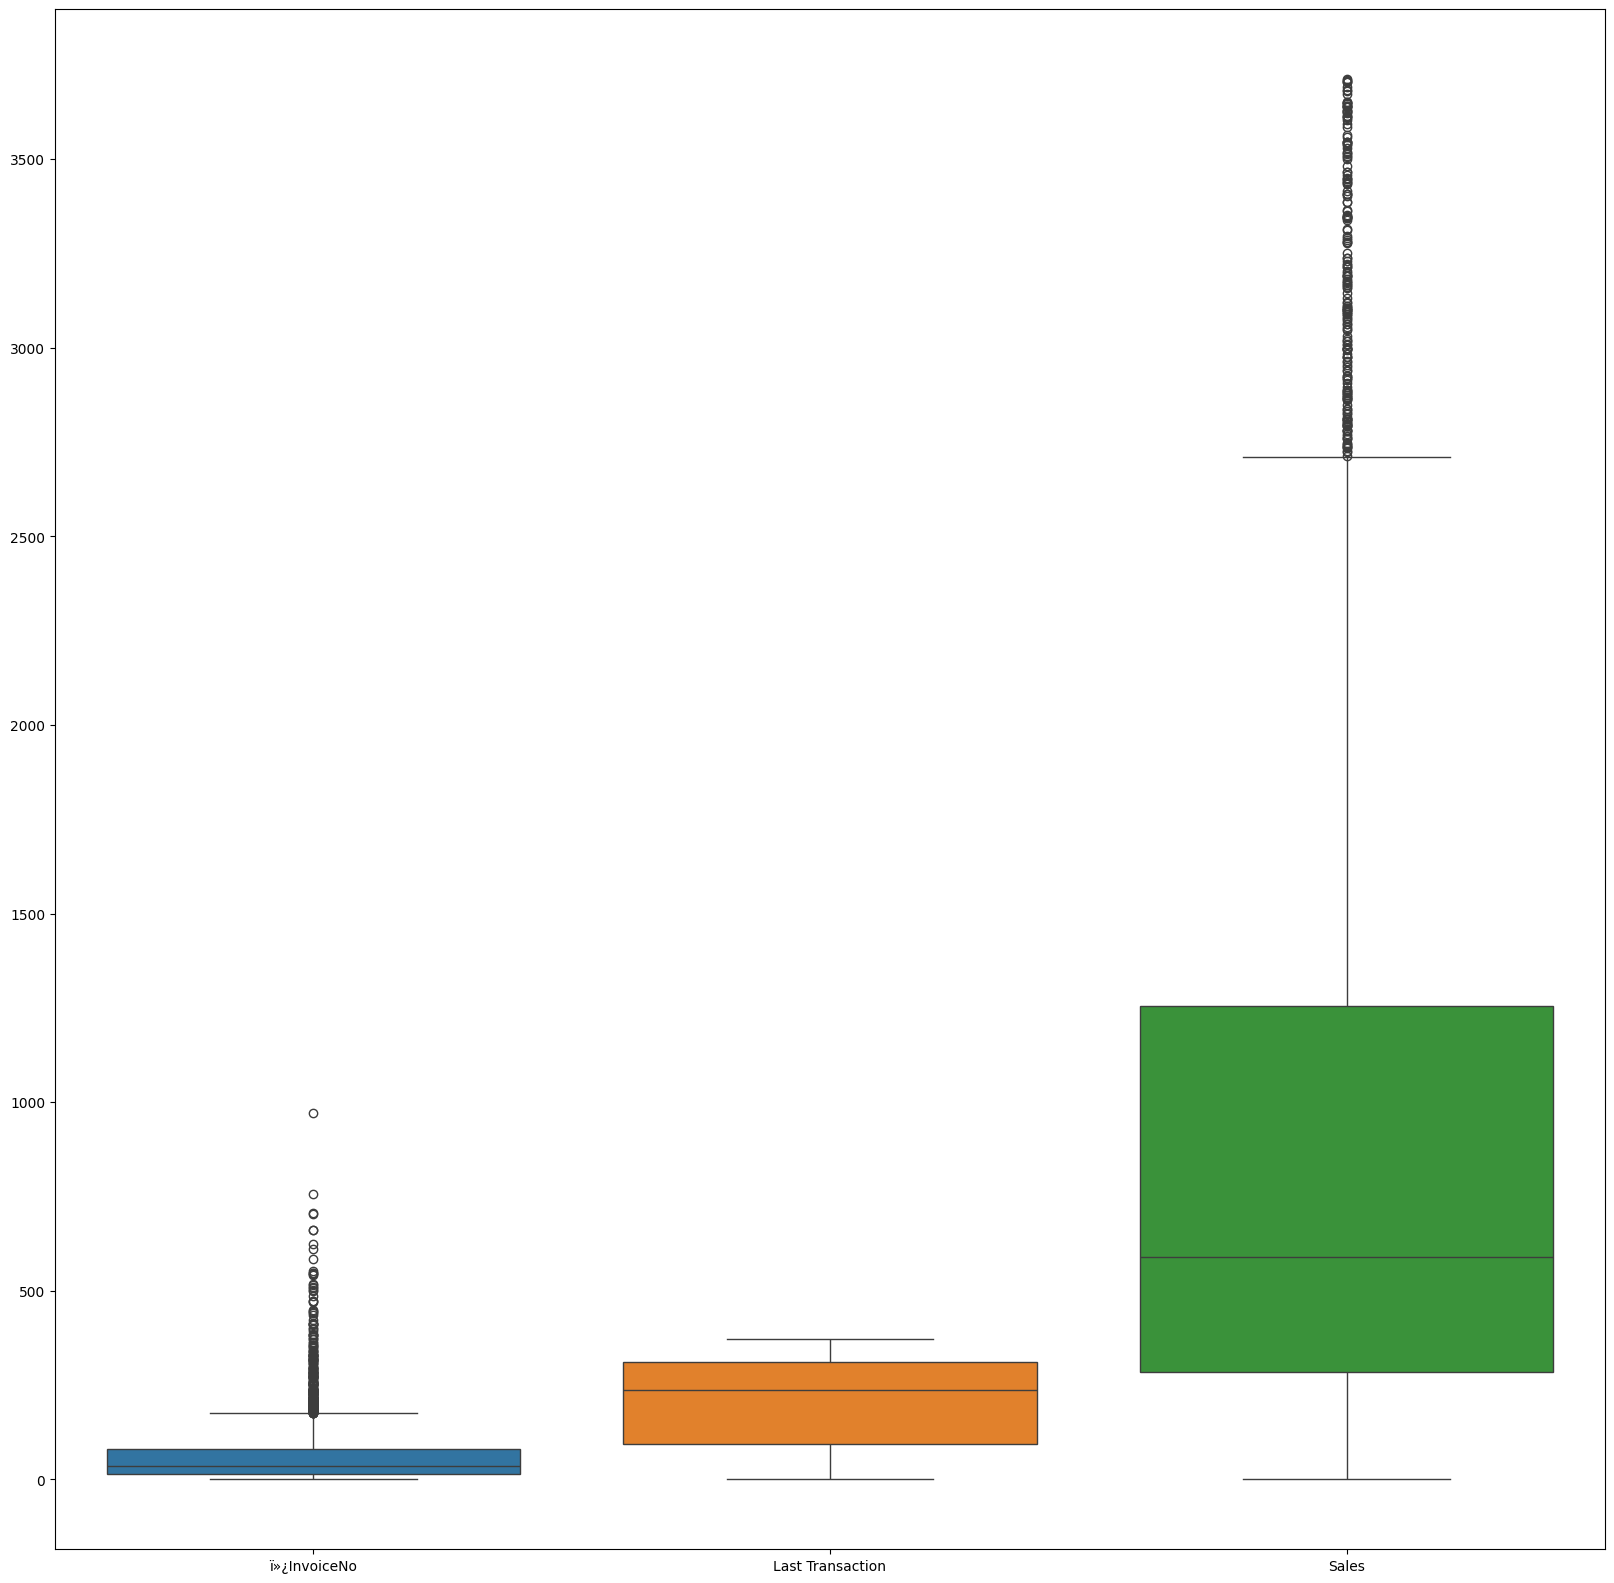

In [30]:
plt.figure(figsize=(20,20))
sns.boxplot(data = new_df_iqr[['ï»¿InvoiceNo', 'Last Transaction', 'Sales']])
plt.show()

In [36]:
new_df_iqr.reset_index(drop = True, inplace = True)
new_df_iqr

,CustomerID,Country,Last Transaction,ï»¿InvoiceNo,Sales
0,12348.0,Finland,357,31,1797.24
1,12349.0,Italy,18,73,1757.55
2,12350.0,Norway,309,17,334.40
3,12352.0,Norway,296,85,2506.04
4,12353.0,Bahrain,203,4,89.00
...,...,...,...,...,...
3918,18280.0,United Kingdom,277,10,180.60
3919,18281.0,United Kingdom,180,7,80.82
3920,18282.0,United Kingdom,125,12,178.05
3921,18283.0,United Kingdom,336,756,2094.88


### Visualiztion of correlation matix using heatmap

In [37]:
plt.figure(figsize=(20,20))
sns.heatmap(new_df_iqr.corr(),cmap='Greens', annot =True )
plt.show()

ValueError: could not convert string to float: 'Finland'

<Figure size 2000x2000 with 0 Axes>

### Normalization of given dataset using MinMaxScaler

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
new2_df = new_df_iqr[['Last Transaction', 'ï»¿InvoiceNo', 'Sales'  ]]
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(new2_df)
scaled_df = pd.DataFrame(scaled_df)
scaled_df.columns = ['Last Transaction','ï»¿InvoiceNo', 'Sales' ]
scaled_df['Country'] = new_df_iqr['Country']
scaled_df

,Last Transaction,ï»¿InvoiceNo,Sales,Country
0,0.957105,0.030960,0.484200,Finland
1,0.048257,0.074303,0.473507,Italy
2,0.828418,0.016512,0.090092,Norway
3,0.793566,0.086687,0.675160,Norway
4,0.544236,0.003096,0.023978,Bahrain
...,...,...,...,...
3918,0.742627,0.009288,0.048656,United Kingdom
3919,0.482574,0.006192,0.021774,United Kingdom
3920,0.335121,0.011352,0.047969,United Kingdom
3921,0.900804,0.779154,0.564388,United Kingdom


### K Means Clusting - Plot the graph using elbow method

In [40]:
df_k = scaled_df.drop(columns= ['Country'], axis = 1)
#Elbow method for K Mean
# Import ElbowVisualizer


In [41]:
#Elbow method for K Mean
# Import ElbowVisualizer
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
# K is range of number of clusters
visualizer = KElbowVisualizer(model, k=(1,11), timings = False)
visualizer.fit(df_k) #fit data to visualizer
visualizer.show()

YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Initialize the model and visualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)

# Fit and render the elbow plot
visualizer.fit(df_k)
visualizer.show()


YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!

In [ ]:
import sys
!{sys.executable} -m pip install yellowbrick


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


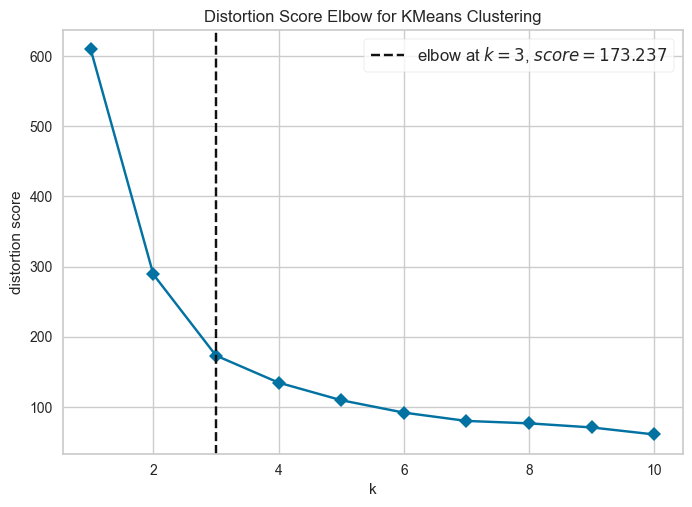

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [42]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

# Added force_model=True to skip type checking
visualizer = KElbowVisualizer(model, k=(1,11), timings=False, force_model=True)

visualizer.fit(df_k)
visualizer.show()


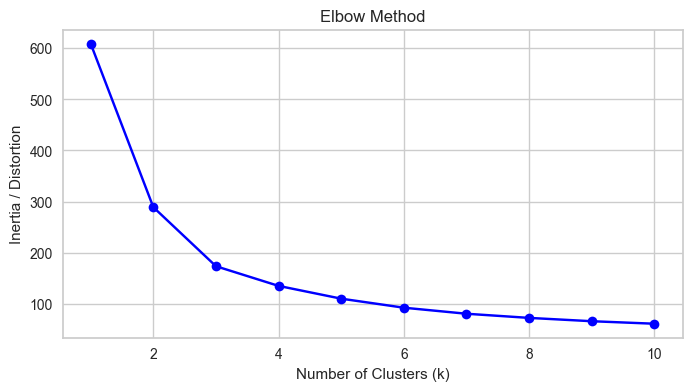

In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Prep data
df_k = scaled_df.drop(columns=['Country'], axis=1)

# Calculate inertia
inertia = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_k)
    inertia.append(model.inertia_)

# Generate the plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / Distortion')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


In [44]:
# km = KMeans(n_clusters = 3 )
# y_predicted = km.fit_predicted(df_k)
# df_k['clusters'] = y_predicted
# df_k

from sklearn.cluster import KMeans

# Initialize the model with 3 clusters
km = KMeans(n_clusters=3, random_state=42)

# Fix: Changed fit_predicted to fit_predict
y_predicted = km.fit_predict(df_k)

# Add the cluster assignments to your DataFrame
df_k['clusters'] = y_predicted

# Display the final DataFrame
df_k


,Last Transaction,ï»¿InvoiceNo,Sales,clusters
0,0.957105,0.030960,0.484200,2
1,0.048257,0.074303,0.473507,0
2,0.828418,0.016512,0.090092,1
3,0.793566,0.086687,0.675160,2
4,0.544236,0.003096,0.023978,1
...,...,...,...,...
3918,0.742627,0.009288,0.048656,1
3919,0.482574,0.006192,0.021774,0
3920,0.335121,0.011352,0.047969,0
3921,0.900804,0.779154,0.564388,2


In [45]:
km.cluster_centers_

array([[0.22076895, 0.04001774, 0.14851301],
       [0.77654069, 0.04300147, 0.15802412],
       [0.79834825, 0.15821687, 0.63465266]])

### We have 3 columns, so we get 3-dimensional data. Remember the lesser the dimension is better the result

### Visualize This 
array([[0.22076895, 0.04001774, 0.14851301],
       [0.77654069, 0.04300147, 0.15802412],
       [0.79834825, 0.15821687, 0.63465266]])

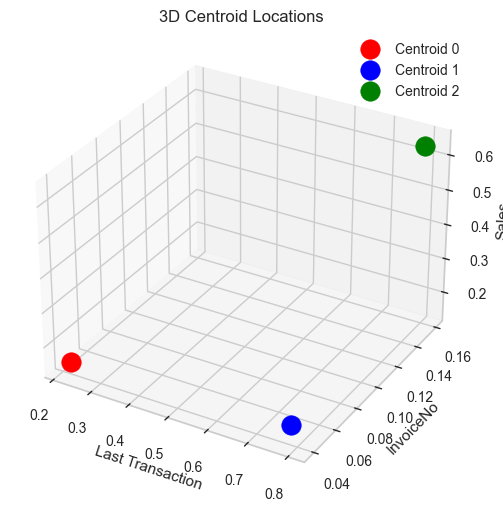

In [46]:
import matplotlib.pyplot as plt
import numpy as np

centroids = np.array(
    [
        [0.22076895, 0.04001774, 0.14851301],
        [0.77654069, 0.04300147, 0.15802412],
        [0.79834825, 0.15821687, 0.63465266],
    ]
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Scatter the 3 centroids with distinct colors
colors = ["red", "blue", "green"]
for i in range(3):
    ax.scatter(
        centroids[i, 0],
        centroids[i, 1],
        centroids[i, 2],
        color=colors[i],
        s=200,
        label=f"Centroid {i}",
    )

ax.set_xlabel("Last Transaction")
ax.set_ylabel("InvoiceNo")
ax.set_zlabel("Sales")
ax.set_title("3D Centroid Locations")
ax.legend()
plt.show()


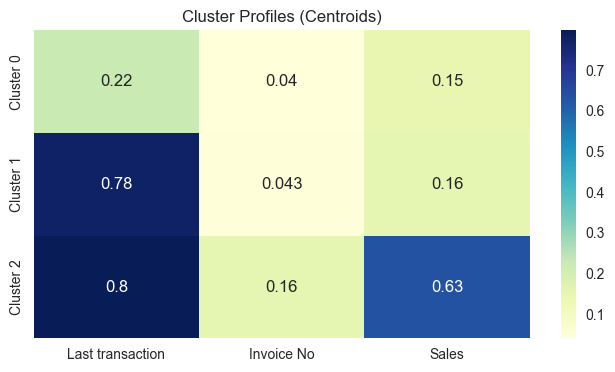

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Your centroids array
centroids = np.array(
    [
        [0.22076895, 0.04001774, 0.14851301],
        [0.77654069, 0.04300147, 0.15802412],
        [0.79834825, 0.15821687, 0.63465266],
    ]
)

feature_names = ["Last transaction", "Invoice No", "Sales"]
cluster_names = ["Cluster 0", "Cluster 1", "Cluster 2"]

plt.figure(figsize=(8, 4))
sns.heatmap(
    centroids,
    annot=True,
    cmap="YlGnBu",
    xticklabels=feature_names,
    yticklabels=cluster_names,
)
plt.title("Cluster Profiles (Centroids)")
plt.show()


### Model Evaluation

In [48]:
km.labels_ # clusters

array([2, 0, 1, ..., 0, 2, 2], shape=(3923,), dtype=int32)

In [49]:
from sklearn.metrics import silhouette_samples, silhouette_score
score = silhouette_score(df_k, km.labels_, metric = 'euclidean')
samples = silhouette_samples(df_k, km.labels_)
print(score)
print(samples)

0.7738234950686357
[0.6967358  0.68489006 0.84123851 ... 0.79999183 0.48435298 0.64982325]


In [50]:
samples


array([0.6967358 , 0.68489006, 0.84123851, ..., 0.79999183, 0.48435298,
       0.64982325], shape=(3923,))

In [54]:
from sklearn.cluster import AgglomerativeClustering
hierarchial = AgglomerativeClustering(n_clusters=3)


y_predicted_hierarchial = hierarchial.fit_predict(df_k)

df_k['clusters_hierarchial'] = y_predicted_hierarchial

df_k.head(30)

,Last Transaction,ï»¿InvoiceNo,Sales,clusters,clusters_hierarchial
0,0.957105,0.030960,0.484200,2,1
1,0.048257,0.074303,0.473507,0,2
2,0.828418,0.016512,0.090092,1,0
3,0.793566,0.086687,0.675160,2,1
4,0.544236,0.003096,0.023978,1,0
5,0.619303,0.058824,0.290805,1,0
6,0.571046,0.012384,0.123768,1,0
7,0.871314,0.059856,0.757436,2,1
8,0.402145,0.018576,0.314691,0,2
9,0.536193,0.132095,0.717194,2,1


Calculate the silhouette_score for hierarchial clustering algorithm.

In [55]:
from sklearn.metrics import silhouette_samples, silhouette_score
score = silhouette_score(df_k, hierarchial.labels_, metric = 'euclidean')
samples = silhouette_samples(df_k, hierarchial.labels_)
print(score)
print(samples)

0.8509778848433895
[0.7772454  0.82948941 0.8791202  ... 0.9027672  0.58851062 0.74124054]


# DBSCAN